# Superstore Sales Data Analysis
– Exploratory Data Analysis (EDA)

## Objective
To analyze Superstore sales data and identify patterns in sales, profit,
customers, products, categories, regions, shipping, and discounts.

## Key Goals
- Understand overall business performance
- Identify profitable and loss-making products
- Analyze customer profitability
- Analyze category and sub-category performance
- Identify high-sales but low-profit states
- Understand the relationship between discount and profit
- Generate actionable business recommendations

2.**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

3.**Load Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/dataset/Superstore.csv", encoding='latin1')
df

Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


4.**Understand The Dataset**

In [3]:
df.head(10)
df.tail(10)
df.shape
df.columns
df.dtypes
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


5.**Data Quality Assesment**

In [4]:
#missing values
df.isnull().sum()
#missing values in percentage
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

missing
#Duplicate Records
df.duplicated().sum()
df = df.drop_duplicates()
#Check Unique Values
df.nunique()

,0
Row ID,9994
Order ID,5009
Order Date,1237
Ship Date,1334
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,531


6.**Convert Data Columns**

In [5]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,11/8/2016,11/11/2016
1,11/8/2016,11/11/2016
2,6/12/2016,6/16/2016
3,10/11/2015,10/18/2015
4,10/11/2015,10/18/2015


In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [7]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


7.**Feature Engineering**

In [8]:
df["Year"] = df["Order Date"].dt.year

In [9]:
df["Month"] = df["Order Date"].dt.month

In [10]:
df["Month Name"] = df["Order Date"].dt.month_name()

In [11]:
df["Ship Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [12]:
df["Profit Margin"] = np.where(
    df["Sales"] != 0,
    (df["Profit"] / df["Sales"]) * 100,
    np.nan
)

8.**Execute KPIs**

In [13]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

profit_margin = (total_profit / total_sales) * 100
average_order_value = total_sales / total_orders
average_profit_per_order = total_profit / total_orders

#total_sales = df["Sales"].sum()

print(f"Total Sales: ₹{total_sales:,.2f}")
#print("Total Sales:", round(total_sales, 2))
print(f"Total Profit: ₹{total_profit:,.2f}")
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Order Value:", round(average_order_value, 2))
print("Average Profit per Order:", round(average_profit_per_order, 2))

Total Sales: ₹2,297,200.86
Total Profit: ₹286,397.02
Total Quantity: 37873
Total Orders: 5009
Total Customers: 793
Profit Margin: 12.47 %
Average Order Value: 458.61
Average Profit per Order: 57.18


9.**Univariate Analysis**

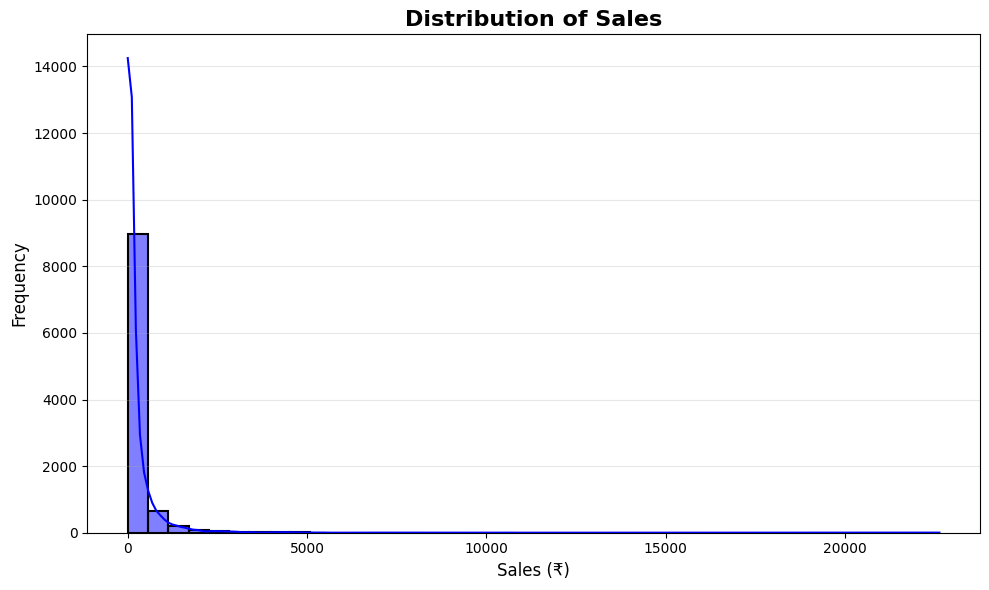

In [52]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], bins=40, kde=True, stat="count",
color="blue",
alpha=0.5,
edgecolor="black",
linewidth=1.5
)
plt.title("Distribution of Sales", fontsize=16, fontweight="bold")
plt.xlabel("Sales (₹)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

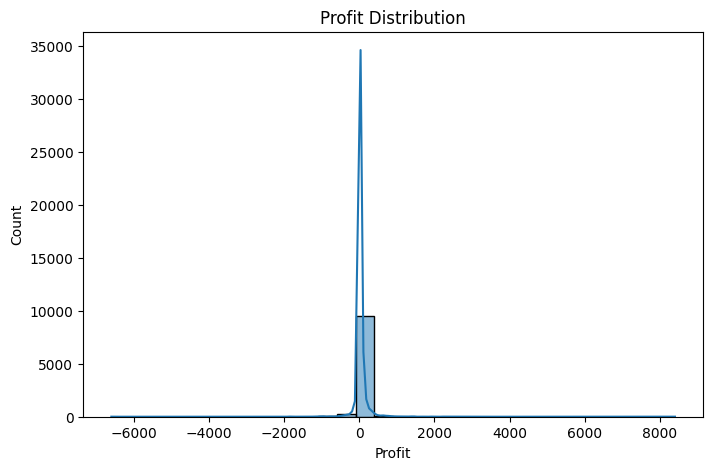

In [15]:
#Profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Profit"], bins=30, kde=True)
plt.title("Profit Distribution")
plt.show()

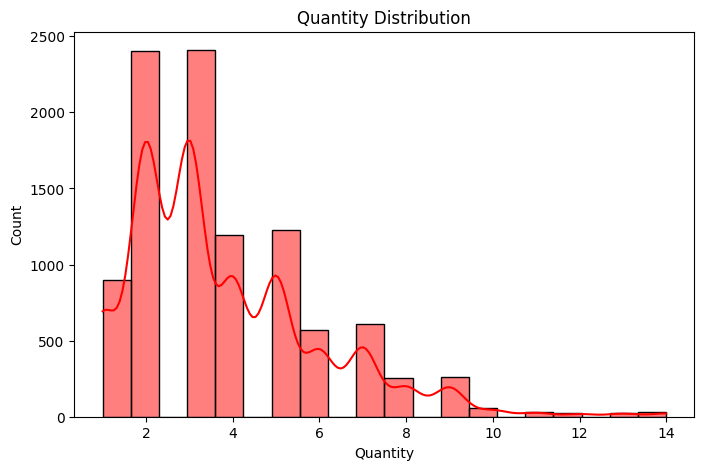

In [56]:
#Quantity Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=20, kde=True,color="red")
plt.title("Quantity Distribution")
plt.show()

10.**Sales And Profit Over Time**

In [17]:
#Yearly Performance
yearly = df.groupby("Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

yearly

,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


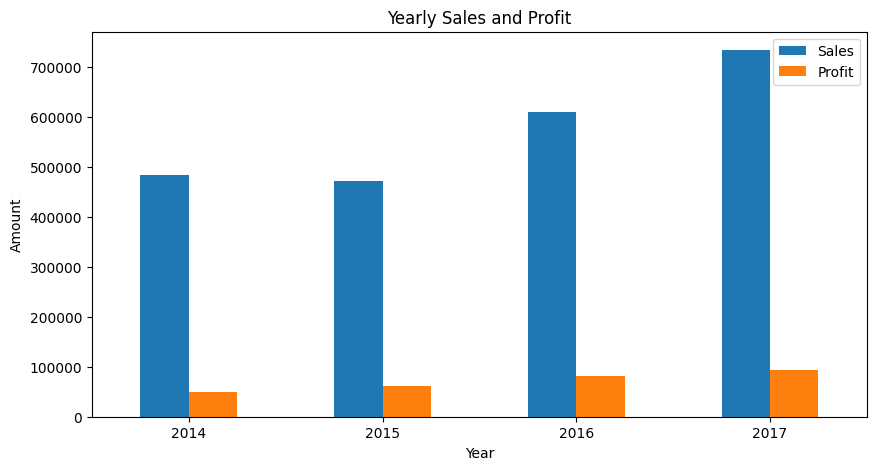

In [18]:
yearly.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Yearly Sales and Profit")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

11.**Monthly Sales Trend**

In [19]:
monthly = (
    df.groupby(["Year", "Month"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

monthly.head()

,Year,Month,Sales,Profit
0,2014,1,14236.895,2450.1907
1,2014,2,4519.892,862.3084
2,2014,3,55691.009,498.7299
3,2014,4,28295.345,3488.8352
4,2014,5,23648.287,2738.7096


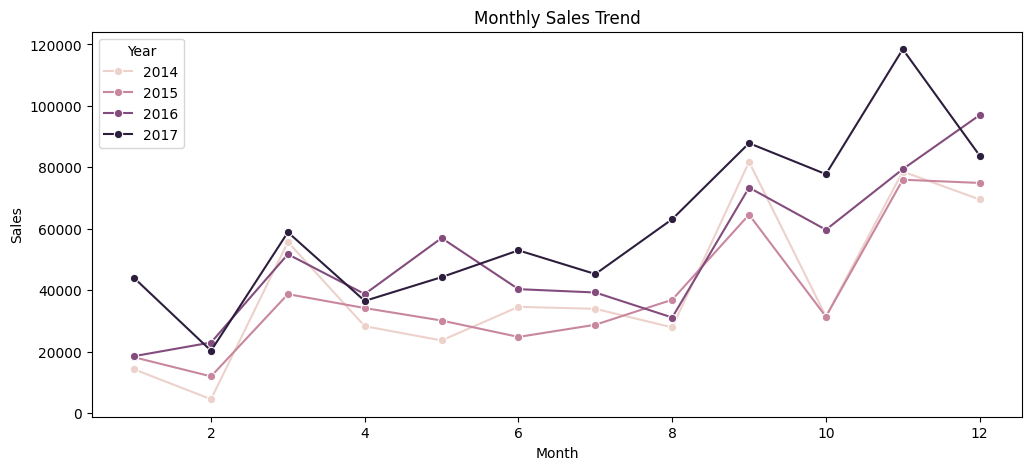

In [20]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.show()

12.**Category Analysis**

In [21]:
category = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique")
      )
)

category["Profit Margin"] = (
    category["Profit"] / category["Sales"] * 100
)

category.sort_values("Profit", ascending=False)

,Sales,Profit,Quantity,Orders,Profit Margin
Category,,,,,
Technology,836154.0330,145454.9481,6939,1544,17.395712
Office Supplies,719047.0320,122490.8008,22906,3742,17.035158
Furniture,741999.7953,18451.2728,8028,1764,2.486695


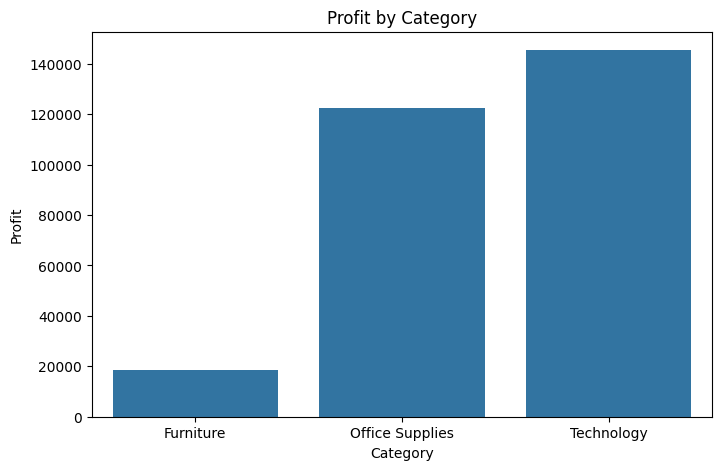

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category.reset_index(),
    x="Category",
    y="Profit"
)

plt.title("Profit by Category")
plt.show()

13.**Sub-Category Analysis**

In [23]:
subcategory = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
)

subcategory["Profit Margin"] = (
    subcategory["Profit"] /
    subcategory["Sales"] * 100
)

subcategory.sort_values("Profit", ascending=False)

,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,
Copiers,149528.0300,55617.8249,234,37.195585
Phones,330007.0540,44515.7306,3289,13.489327
Accessories,167380.3180,41936.6357,2976,25.054700
Paper,78479.2060,34053.5693,5178,43.391837
Binders,203412.7330,30221.7633,5974,14.857361
Chairs,328449.1030,26590.1663,2356,8.095673
Storage,223843.6080,21278.8264,3158,9.506113
Appliances,107532.1610,18138.0054,1729,16.867517
Furnishings,91705.1640,13059.1436,3563,14.240358


In [24]:
print("Top 10 Sub-Categories")
display(subcategory.sort_values("Profit", ascending=False).head(10))

print("Bottom 10 Sub-Categories")
display(subcategory.sort_values("Profit").head(10))

Top 10 Sub-Categories


,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,
Copiers,149528.030,55617.8249,234,37.195585
Phones,330007.054,44515.7306,3289,13.489327
Accessories,167380.318,41936.6357,2976,25.054700
Paper,78479.206,34053.5693,5178,43.391837
Binders,203412.733,30221.7633,5974,14.857361
Chairs,328449.103,26590.1663,2356,8.095673
Storage,223843.608,21278.8264,3158,9.506113
Appliances,107532.161,18138.0054,1729,16.867517
Furnishings,91705.164,13059.1436,3563,14.240358


Bottom 10 Sub-Categories


,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241,-8.564460
Bookcases,114879.9963,-3472.5560,868,-3.022768
Supplies,46673.5380,-1189.0995,647,-2.547695
Fasteners,3024.2800,949.5182,914,31.396504
Machines,189238.6310,3384.7569,440,1.788618
Labels,12486.3120,5546.2540,1400,44.418672
Art,27118.7920,6527.7870,3000,24.071083
Envelopes,16476.4020,6964.1767,906,42.267582
Furnishings,91705.1640,13059.1436,3563,14.240358


14.**Product Analysis**

In [25]:
product = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
)

product.sort_values("Sales", ascending=False).head(10)

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


In [26]:
#Top Profitable Product
product.sort_values("Profit", ascending=False).head(10)

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38
Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24
Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13


In [27]:
#Loss Making Product
product[product["Profit"] < 0].sort_values("Profit").head(10)

,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


15.**Customer Profitability Analysis**

In [28]:
customer = (
    df.groupby("Customer Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

customer["Profit Margin"] = (
    customer["Profit"] /
    customer["Sales"] * 100
)

In [29]:
#Top customers by sales:
customer.sort_values("Sales", ascending=False).head(10)

,Sales,Profit,Orders,Profit Margin
Customer Name,,,,
Sean Miller,25043.050,-1980.7393,5,-7.909337
Tamara Chand,19052.218,8981.3239,5,47.140569
Raymond Buch,15117.339,6976.0959,6,46.146322
Tom Ashbrook,14595.620,4703.7883,4,32.227396
Adrian Barton,14473.571,5444.8055,10,37.618950
Ken Lonsdale,14175.229,806.8550,12,5.692007
Sanjit Chand,14142.334,5757.4119,9,40.710479
Hunter Lopez,12873.298,5622.4292,6,43.675127
Sanjit Engle,12209.438,2650.6769,11,21.710065


In [30]:
#Top customers by profit:
customer.sort_values("Profit", ascending=False).head(10)

,Sales,Profit,Orders,Profit Margin
Customer Name,,,,
Tamara Chand,19052.218,8981.3239,5,47.140569
Raymond Buch,15117.339,6976.0959,6,46.146322
Sanjit Chand,14142.334,5757.4119,9,40.710479
Hunter Lopez,12873.298,5622.4292,6,43.675127
Adrian Barton,14473.571,5444.8055,10,37.618950
Tom Ashbrook,14595.620,4703.7883,4,32.227396
Christopher Martinez,8954.020,3899.8904,4,43.554631
Keith Dawkins,8181.256,3038.6254,12,37.141307
Andy Reiter,6608.448,2884.6208,6,43.650503


16.**Customer Classification**

In [31]:
sales_median = customer["Sales"].median()
margin_median = customer["Profit Margin"].median()

def classify_customer(row):

    if row["Profit"] < 0:
        return "Money-Loser"

    elif row["Sales"] >= sales_median and row["Profit Margin"] >= margin_median:
        return "Star"

    elif row["Sales"] >= sales_median and row["Profit Margin"] < margin_median:
        return "Vanity"

    else:
        return "Efficient"


customer["Customer Type"] = customer.apply(
    classify_customer,
    axis=1
)

In [32]:
#summary
customer.groupby("Customer Type").agg(
    Customers=("Customer Type", "count"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Avg_Margin=("Profit Margin", "mean")
)

,Customers,Sales,Profit,Avg_Margin
Customer Type,,,,
Efficient,309,3.616574e+05,61974.4701,18.349149
Money-Loser,155,3.919504e+05,-71224.4744,-17.961645
Star,206,1.017896e+06,253351.0318,23.638143
Vanity,123,5.256967e+05,42295.9942,8.023434


17.**Geographic Analysis**

In [33]:
region = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
)

region["Profit Margin"] = (
    region["Profit"] /
    region["Sales"] * 100
)

region.sort_values("Profit", ascending=False)

,Sales,Profit,Profit Margin
Region,,,
West,725457.8245,108418.4489,14.944831
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
Central,501239.8908,39706.3625,7.921629


18.**High Sales but Poor Profitability States**

In [34]:
state = (
    df.groupby("State")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

state["Profit Margin"] = (
    state["Profit"] /
    state["Sales"] * 100
)

sales_median = state["Sales"].median()
margin_median = state["Profit Margin"].median()

high_sales_low_profit = state[
    (state["Sales"] >= sales_median) &
    (state["Profit Margin"] < margin_median)
].sort_values("Profit Margin")

high_sales_low_profit

,Sales,Profit,Orders,Profit Margin
State,,,,
Ohio,78258.1360,-16971.3766,236,-21.686405
Colorado,32108.1180,-6527.8579,79,-20.330864
Tennessee,30661.8730,-5341.6936,91,-17.421289
Illinois,80166.1010,-12607.8870,276,-15.727205
Texas,170188.0458,-25729.3563,487,-15.118192
North Carolina,55603.1640,-7490.9122,136,-13.472097
Pennsylvania,116511.9140,-15559.9603,288,-13.354823
Arizona,35282.0010,-3427.9246,108,-9.715789
Florida,89473.7080,-3399.3017,200,-3.799219


19.**Segment Analysis**

In [35]:
segment = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

segment["Profit Margin"] = (
    segment["Profit"] /
    segment["Sales"] * 100
)

segment

,Sales,Profit,Orders,Profit Margin
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,11.548050
Corporate,7.061464e+05,91979.1340,1514,13.025506
Home Office,4.296531e+05,60298.6785,909,14.034269


20.**Shiping Analysis**

In [36]:
shipping = (
    df.groupby("Ship Mode")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Avg_Ship_Days=("Ship Days", "mean")
      )
)

shipping["Profit Margin"] = (
    shipping["Profit"] /
    shipping["Sales"] * 100
)

shipping

,Sales,Profit,Orders,Avg_Ship_Days,Profit Margin
Ship Mode,,,,,
First Class,3.514284e+05,48969.8399,787,2.182705,13.934513
Same Day,1.283631e+05,15891.7589,264,0.044199,12.380315
Second Class,4.591936e+05,57446.6354,964,3.238046,12.510331
Standard Class,1.358216e+06,164088.7875,2994,5.006535,12.081202


21.**Discount Analysis**

In [37]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
)

discount_analysis["Profit Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
)

discount_analysis

,Sales,Profit,Quantity,Profit Margin
Discount,,,,
0.00,1.087908e+06,320987.6032,18267,29.505019
0.10,5.436935e+04,9029.1770,373,16.607108
0.15,2.755852e+04,1418.9915,198,5.149012
0.20,7.645944e+05,90337.3060,13660,11.815063
0.30,1.032267e+05,-10369.2774,849,-10.045155
0.32,1.449346e+04,-2391.1377,105,-16.498047
0.40,1.164178e+05,-23057.0504,786,-19.805437
0.45,5.484974e+03,-2493.1111,45,-45.453472
0.50,5.891854e+04,-20506.4281,241,-34.804712


In [38]:
df["Discount"].corr(df["Profit"])

np.float64(-0.21948745637176803)

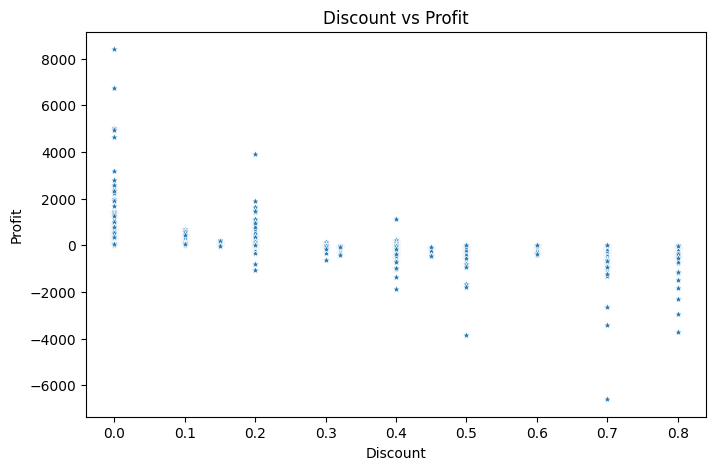

In [66]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    marker="*",
    sizes=(50, 100)
)

plt.title("Discount vs Profit")
plt.show()

22.**Quantity vs Profit**

In [40]:
quantity_analysis = (
    df.groupby("Quantity")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

quantity_analysis

,Sales,Profit,Orders
Quantity,,,
1,53251.9345,7440.4801,830
2,289091.4798,38448.4088,1931
3,422060.6007,57015.5250,1919
4,323670.9944,44223.3908,1071
5,415661.6965,49516.5945,1080
6,207122.3214,10325.4678,539
7,239908.3659,34286.9730,579
8,117760.1760,10856.7960,248
9,128505.5901,17687.8908,252


In [41]:
df["Quantity"].corr(df["Profit"])

np.float64(0.06625318912428488)

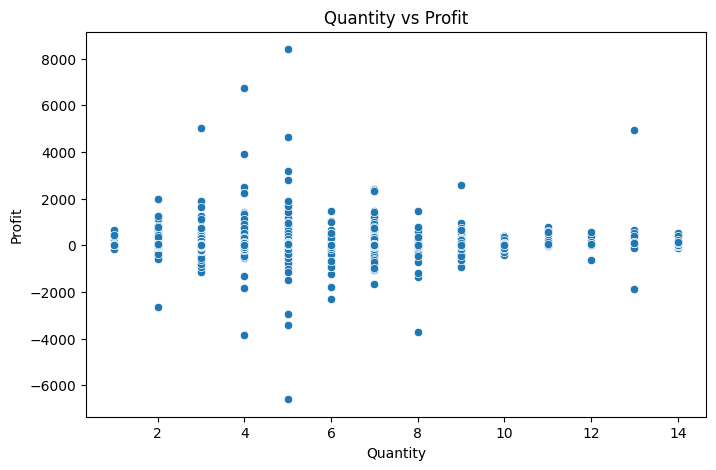

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Profit"
)

plt.title("Quantity vs Profit")
plt.show()

23.**Loss Analysis**

In [43]:
loss_df = df[df["Profit"] < 0]

print("Loss-making transactions:", len(loss_df))
print(
    "Loss-making percentage:",
    round(len(loss_df) / len(df) * 100, 2),
    "%"
)

Loss-making transactions: 1871
Loss-making percentage: 18.72 %


In [44]:
#loss by category
loss_df.groupby("Category")["Profit"].sum().sort_values()

,Profit
Category,
Furniture,-60936.1090
Office Supplies,-56615.2585
Technology,-38579.9182


In [45]:
#loss by sub_category
loss_df.groupby("Sub-Category")["Profit"].sum().sort_values()

,Profit
Sub-Category,
Binders,-38510.4964
Tables,-32412.1483
Machines,-30118.6682
Bookcases,-12152.2060
Chairs,-9880.8413
Appliances,-8629.6412
Phones,-7530.6235
Furnishings,-6490.9134
Storage,-6426.3038


In [46]:
#loss by state
loss_df.groupby("State")["Profit"].sum().sort_values().head(10)

,Profit
State,
Texas,-36813.1875
Ohio,-21750.0002
Pennsylvania,-21602.8515
Illinois,-19501.6975
North Carolina,-11557.9854
Colorado,-8900.9048
Florida,-8689.8295
Tennessee,-7257.0174
Arizona,-6656.7675


24.**Correlation Analysis**

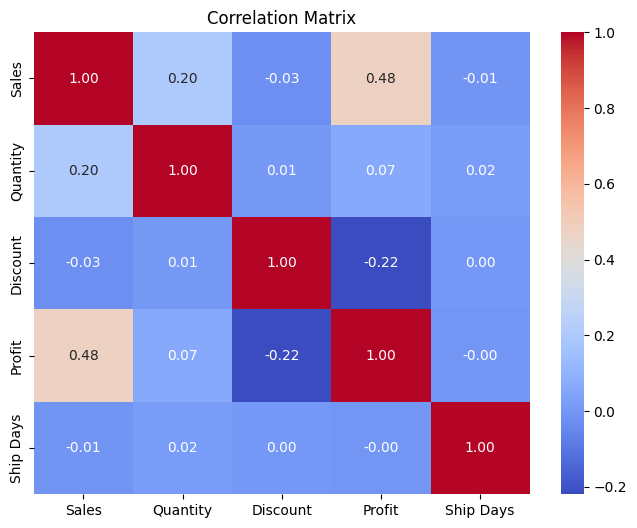

In [47]:
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Ship Days"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

25.**Outlier Analysis**

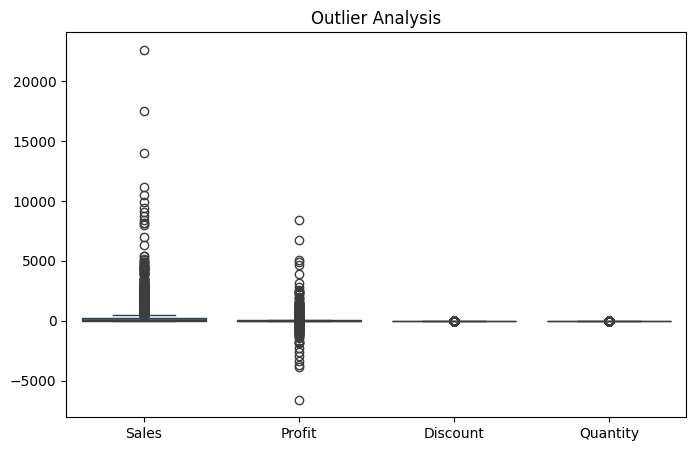

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[["Sales", "Profit", "Discount", "Quantity"]]
)

plt.title("Outlier Analysis")
plt.show()

26.**Pareto Analysis**

In [49]:
product_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

positive_profit = product_profit[product_profit > 0]

cumulative = positive_profit.cumsum()
total = positive_profit.sum()

cumulative_percentage = cumulative / total * 100

pareto = pd.DataFrame({
    "Profit": positive_profit,
    "Cumulative %": cumulative_percentage
})

pareto.head(20)

,Profit,Cumulative %
Product Name,,
Canon imageCLASS 2200 Advanced Copier,25199.9280,6.933240
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390,9.066328
Hewlett Packard LaserJet 3310 Copier,6983.8836,10.987800
Canon PC1060 Personal Laser Copier,4570.9347,12.245398
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766,13.372046
Ativa V4110MDD Micro-Cut Shredder,3772.9461,14.410095
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714,15.433018
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820,16.449973
Ibico EPK-21 Electric Binding System,3345.2823,17.370359


In [50]:
(pareto["Cumulative %"] <= 80).sum()

np.int64(341)

# Key Business Findings

1. Sales and profit performance varies across years and months.
2. Some categories and sub-categories contribute significantly more to profitability.
3. High-sales products are not always the most profitable products.
4. Some customers generate high revenue but relatively low profit margins.
5. Some states generate high sales but comparatively poor profitability.
6. Higher discounts are associated with weaker profitability in the analysis.
7. Loss-making products and sub-categories require further investigation.
8. A smaller group of products contributes a large share of positive profit.

# Business Recommendations

1. Prioritize products with high sales, strong profit and healthy margins.

2. Review consistently loss-making and low-margin products before
   deciding whether to reprice, reduce discounts or discontinue them.

3. Focus on high-profit categories and sub-categories.

4. Evaluate customers using both sales and profitability rather than
   treating high-sales customers as automatically valuable.

5. Retain Star customers and develop Efficient customers while reviewing
   Vanity and Money-Loser customers.

6. Use discounts strategically instead of applying broad discounts.
   Consider product margin, demand, quantity and profitability.

7. Investigate high-sales but low-profit states to identify pricing,
   discount, product-mix or shipping issues.

8. Improve shipping efficiency where delivery time is high and the
   business benefit is limited.

29.**Final Conclusion**

The analysis shows that Superstore should not evaluate business
performance using sales alone. Profitability, product performance,
customer value, discounts, geography and shipping efficiency are also
important.

The business can improve sustainable growth by focusing on profitable
products and categories, identifying valuable customers, reviewing
loss-making products and states, and using discounts strategically.

Overall, the analysis supports a shift from a purely sales-focused
strategy toward a profitability-focused strategy.